In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [19]:
train_dir = "/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_train/seg_train"
test_dir = "/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_test/seg_test"
pred_dir = "/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_pred"

import os
from PIL import Image

def inspect_image(path):
    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.png', 'jpg', 'jpeg')):
                img_path = os.path.join(root, file)
                with Image.open(img_path) as img:
                    return img.size
    raise FileNotFoundError(f"Valid image doesn't exist in the folder {path}")

train_img_size = inspect_image(train_dir)
test_img_size = inspect_image(test_dir)

print(f"Training image size: {train_img_size}")
print(f"Test image size: {test_img_size}")

Training image size: (150, 150)
Test image size: (150, 150)


## Data transforms

In [20]:
# define the transforms

torch.manual_seed(5)

train_transform = v2.Compose([
    v2.Resize((150,150)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(10),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    )
])

test_transform = v2.Compose([
    v2.Resize((150,150)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    )
])

display_transform = v2.Compose([
    v2.Resize((150, 150))
])

## Comparing a normal image to normalized image

## Loading dataset and data loaders

In [21]:
from torchvision.datasets import ImageFolder

training_dataset = ImageFolder(root=train_dir, transform=train_transform)
testing_dataset = ImageFolder(root=test_dir, transform=test_transform)

training_loader = DataLoader(dataset=training_dataset, batch_size=64, shuffle=True, num_workers=6)
testing_loader = DataLoader(dataset=testing_dataset, batch_size=64, num_workers=6)

## Offload the work to GPU (if available)

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## Defining our NN models
We shall be testing out:
1. Normal CNN (baseline) - done
2. \+ BatchNorm
3. \+ Dropout
4. \+ Data augmentation

In [23]:
import math

def give_size(existing, padding, kernel, stride):
    print(math.floor((existing + 2*padding - kernel)/stride) + 1)

give_size(74, 1, 3, 1)
give_size(36, 0, 3, 2)

74
17


### 1. Baseline CNN

In [24]:
# Normal CNN

class CNN_baseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(                                              # (150+2(1)-3)/1 + 1 = 148; (3, 150, 150) -> (32, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # (148+2(0)-3)/2 + 1 = 74;  (32, 150, 150) -> (32, 74, 74)
            nn.Conv2d(                                              # (74+2(1)-3)/1 + 1 = 70;   (32, 74, 74) -> (64, 74, 74)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # (74+2(0)-3)/2 + 1 = 36; (64, 74, 74) -> (64, 36, 36)
            nn.Conv2d(                                              # (36+2(1)-3)/1 + 1 = 36;   (64, 36, 36) -> (128, 36, 36)
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # (36+2(0)-3)/2 + 1 = 17; (128, 36, 36) -> (128, 17, 17)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),                                           # 128*17*17 = 36992,
            nn.Linear(128*17*17, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

base_cnn = CNN_baseline().to(device)

In [25]:
# total number of trainable parameters
num_params = sum(
    p.numel()
    for p in base_cnn.parameters()
    if p.requires_grad
)

print(f"{num_params:,}")

19,100,102


In [26]:
# loss, optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    params=base_cnn.parameters(),
    lr=1e-3
)

In [27]:
# metrics storage

training_acc_1 = []
training_loss_1 = []
validation_acc_1 = []
validation_loss_1 = []

In [28]:
# training function

def train_one_epoch1(model, loader):
    model.train()

    running_loss = 0
    correct  = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [29]:
# validation function

def validation(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [30]:
# training loop

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch1(
        base_cnn, training_loader
    )
    val_loss, val_acc = validation(
        base_cnn, testing_loader
    )

    training_loss_1.append(train_loss)
    training_acc_1.append(train_acc)
    validation_loss_1.append(val_loss)
    validation_acc_1.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

Epoch  1 | Train Loss 0.8972 | Train Acc 0.6588 | Val Loss 0.6096 | Val Acc 0.7863
Epoch  2 | Train Loss 0.5707 | Train Acc 0.7936 | Val Loss 0.5461 | Val Acc 0.8117
Epoch  3 | Train Loss 0.4845 | Train Acc 0.8282 | Val Loss 0.6558 | Val Acc 0.7680
Epoch  4 | Train Loss 0.4283 | Train Acc 0.8466 | Val Loss 0.4823 | Val Acc 0.8333
Epoch  5 | Train Loss 0.3839 | Train Acc 0.8606 | Val Loss 0.4484 | Val Acc 0.8440
Epoch  6 | Train Loss 0.3328 | Train Acc 0.8805 | Val Loss 0.3943 | Val Acc 0.8637
Epoch  7 | Train Loss 0.3049 | Train Acc 0.8924 | Val Loss 0.4211 | Val Acc 0.8567
Epoch  8 | Train Loss 0.2748 | Train Acc 0.8977 | Val Loss 0.4562 | Val Acc 0.8593
Epoch  9 | Train Loss 0.2409 | Train Acc 0.9114 | Val Loss 0.5158 | Val Acc 0.8360
Epoch 10 | Train Loss 0.2137 | Train Acc 0.9216 | Val Loss 0.4690 | Val Acc 0.8550
Epoch 11 | Train Loss 0.2004 | Train Acc 0.9281 | Val Loss 0.4877 | Val Acc 0.8583
Epoch 12 | Train Loss 0.1738 | Train Acc 0.9379 | Val Loss 0.5424 | Val Acc 0.8450
Epoc

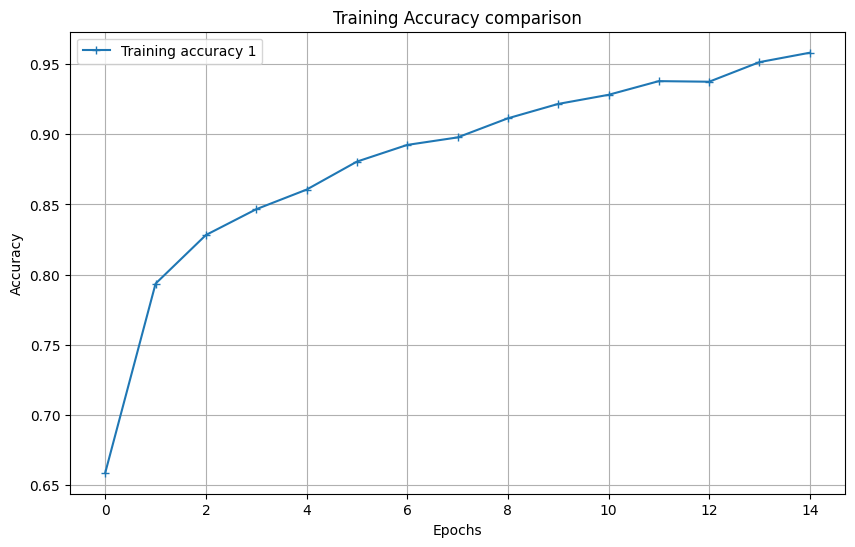

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(training_acc_1, label="Training accuracy 1", marker='+')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy comparison")
plt.grid(True)
plt.legend()
plt.show()

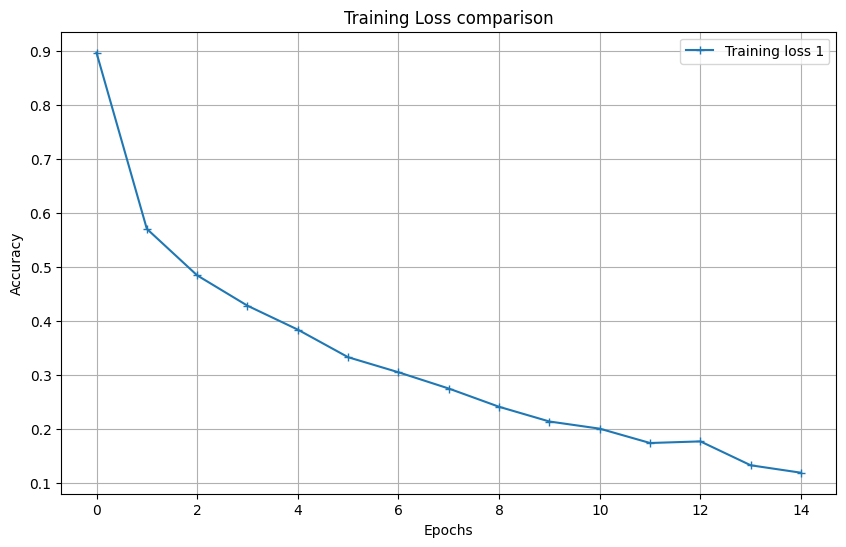

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(training_loss_1, label="Training loss 1", marker='+')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Loss comparison")
plt.grid(True)
plt.legend()
plt.show()

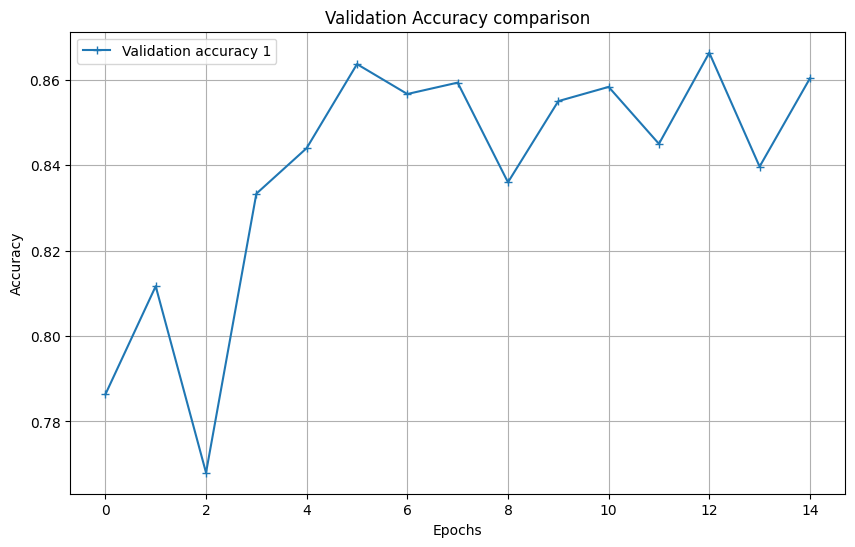

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(validation_acc_1, label="Validation accuracy 1", marker='+')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy comparison")
plt.grid(True)
plt.legend()
plt.show()

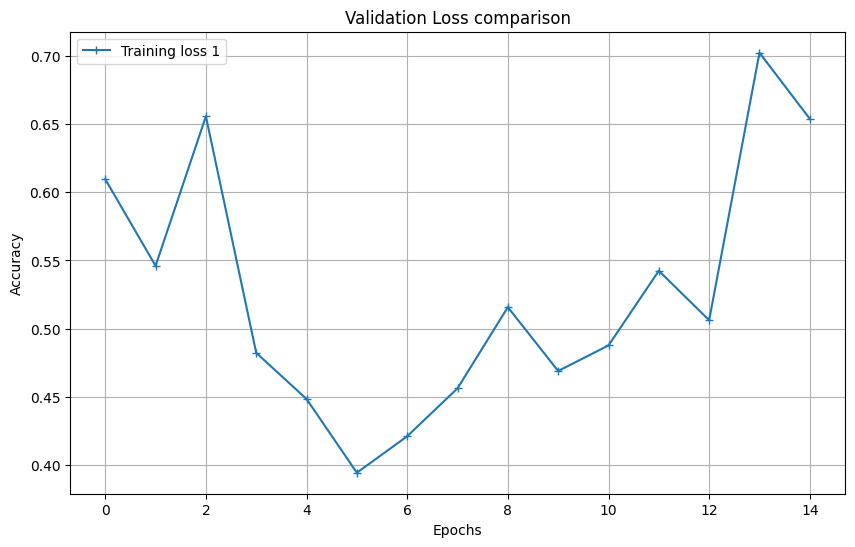

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(validation_loss_1, label="Training loss 1", marker='+')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Loss comparison")
plt.grid(True)
plt.legend()
plt.show()